# Tutorial 5: Storage and Rate

Tutorial 4 ended with a table: every named information quantity is `I(A; B | C)`
under a different choice of time offsets. This tutorial works through the first
half of that table, the quantities that are either about a single process or
symmetric between two.

There are six of them, and they answer genuinely different questions:

| Quantity | Question it answers |
|---|---|
| Active information storage | How much of what a process does next was already implied by its past? |
| Excess entropy | How much of its whole future was implied by its past? |
| Instantaneous MI | How much do two processes share at the same instant? |
| Block MI | How much do two windows share? |
| MI rate | How much do two processes share per unit time? |
| Cross-predictive information | How much of Y's future was implied by X's past? |

Every one is checked against its exact value, which is the point of working on
an oracle. You will see how close a neural estimate gets, in which direction it
errs, and why. That comparison is not available on real data, which is exactly
why it is worth doing once on data where it is.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi.generators import SharedLatentGaussian

SCALE = 1
np.random.seed(0)

oracle = SharedLatentGaussian(dims={'x': 4, 'y': 4}, d=2, phi=0.9, seed=0)
data = oracle.sample(T=int(8000 * SCALE), seed=0)
x, y = data['x'], data['y']

# One model and training config, reused everywhere, so differences between
# quantities are about the quantities rather than about tuning.
MODEL = nmi.Model(embedding_dim=32, hidden_dim=128, n_layers=2)
TRAINING = nmi.Training(n_epochs=int(60 * SCALE), patience=20, batch_size=128)
FIT = dict(model=MODEL, training=TRAINING, n_workers=1, seed=0, show_progress=False)

print(f"tau  = {oracle.tau:.2f} bins")
print(f"rate = {oracle.mi_rate():.4f} bits per bin")
print(f"data : x {x.shape}, y {y.shape}")

tau  = 9.49 bins
rate = 0.8368 bits per bin
data : x (8000, 4), y (8000, 4)


## 1. What a process says about itself

Start with one process and ignore the other entirely. Even alone, a time series
carries information: if it is not white noise, its past tells you something
about its future. Two quantities measure that, and the difference between them
is the interesting part.

**Active information storage** is `I(X_past; X_0)`. How much does the history
tell you about the *very next* value? Lizier introduced it to capture the
storage a process is actually *using* at each update.

**Excess entropy** is `I(X_past; X_future)`. How much does the history tell you
about the *entire* future? This is the total storage the process *holds*,
whether or not it is used at any given step.

The relationship is forced: a longer future can only reveal more, so

$$\text{AIS} \;\le\; E_X$$

always. Storage in use cannot exceed storage held. Let us check that it does.

In [2]:
K = 20
x_past   = [('x', s) for s in range(-K, 0)]
x_now    = [('x', 0)]
x_future = [('x', s) for s in range(0, K)]

ais    = oracle.exact(x_past, x_now)
excess = oracle.exact(x_past, x_future)

print(f"active information storage  I(X_past; X_0)      = {ais:.4f} bits")
print(f"excess entropy              I(X_past; X_future) = {excess:.4f} bits")
print()
print(f"AIS <= E_X ?  {ais <= excess}     (held minus in use = {excess - ais:.4f} bits)")

active information storage  I(X_past; X_0)      = 1.0497 bits
excess entropy              I(X_past; X_future) = 1.2136 bits

AIS <= E_X ?  True     (held minus in use = 0.1639 bits)


Both need a history length. As in Tutorial 4, `k` is a model order rather than
an estimand, so the way to choose it is to raise it until the answer stops
moving. Watch both converge.

In [3]:
k_values = [1, 2, 3, 5, 8, 12, 20, 30]
ais_k    = [oracle.exact([('x', s) for s in range(-k, 0)], x_now) for k in k_values]
excess_k = [oracle.exact([('x', s) for s in range(-k, 0)],
                         [('x', s) for s in range(0, k)]) for k in k_values]

print(f"{'k':>4} {'AIS':>10} {'E_X':>10}")
for k, a, e in zip(k_values, ais_k, excess_k):
    same = "   <- identical: a 1-step future IS the next value" if k == 1 else ""
    print(f"{k:>4} {a:10.6f} {e:10.6f}{same}")

   k        AIS        E_X
   1   0.930899   0.930899   <- identical: a 1-step future IS the next value
   2   1.019646   1.128657
   3   1.039909   1.184007
   5   1.048420   1.209694
   8   1.049602   1.213393
  12   1.049660   1.213578
  20   1.049661   1.213581
  30   1.049661   1.213581


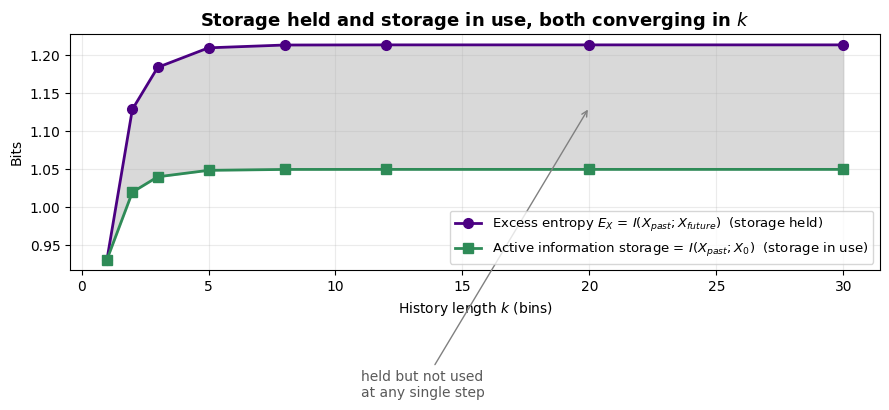

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_values, excess_k, 'o-', color='indigo', lw=2, ms=7,
        label='Excess entropy $E_X$ = $I(X_{past}; X_{future})$  (storage held)')
ax.plot(k_values, ais_k, 's-', color='seagreen', lw=2, ms=7,
        label='Active information storage = $I(X_{past}; X_0)$  (storage in use)')
ax.fill_between(k_values, ais_k, excess_k, color='0.85', zorder=0)
ax.annotate('held but not used\nat any single step',
            xy=(20, (ais_k[-2] + excess_k[-2]) / 2), xytext=(11, 0.75),
            fontsize=10, color='0.35',
            arrowprops=dict(arrowstyle='->', color='0.5'))

ax.set_xlabel('History length $k$ (bins)')
ax.set_ylabel('Bits')
ax.set_title('Storage held and storage in use, both converging in $k$',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Three things are visible.

**They coincide at `k = 1`.** With a one-step future, "the whole future" is just
"the next value", so excess entropy *is* active information storage. They
separate as the future window grows, and the gap is the storage the process
holds without spending it on the next step.

**Both converge, and they converge at different rates.** Active information
storage settles by about `k = 8`, excess entropy takes until roughly `k = 12`.
The longer target needs more history to pin down.

**The shaded gap is a real quantity.** Here it is about 0.16 bits, roughly 13%
of the total held. A process where the gap is near zero spends everything it
stores immediately; one where the gap is large is holding structure that only
pays off further out.

## 2. The quantity that is deliberately missing

You may expect **entropy rate** here, `H(X_0 | X_past)`, since it is the other
standard single-process quantity. It is not in this library, and the reason is
worth stating.

Entropy rate is not a mutual information. It is a conditional entropy, and for
continuous variables a differential entropy is **coordinate-dependent**: rescale
your data from volts to millivolts and the number changes, with no change in
the underlying process. Mutual information does not have that problem, because
the coordinate-dependent parts cancel between the joint and the marginals.

Every estimator in this library is built on that cancellation, so it can report
mutual informations and cannot report entropies. If you need an entropy rate,
discretise your data first and use a plug-in estimator, and be aware the answer
then depends on your discretisation.

## 3. Two processes, symmetric

Now bring Y back. Four quantities, and they differ only in which offsets go into
each group.

**Instantaneous MI**, `I(X_0; Y_0)`, is the same-instant coupling. No history on
either side.

**Block MI**, `I(X_1..w; Y_1..w)`, is Tutorial 4's extensive quantity. It grows
with the window and does not compare across window sizes.

**MI rate** is the intensive version, in bits per bin. Note the offsets: X gets
a **two-sided** window while Y is conditioned on its own past. The two-sidedness
is not a detail. A shared latent makes each process carry information about the
other's future as well as its past, so a causal one-sided window measures
something strictly smaller. Tutorial 6 returns to why.

**Cross-predictive information**, `I(X_past; Y_future)`, asks how much of Y's
future was already implied by X's past. This is the quantity Palmer and
colleagues used to ask whether retinal ganglion cells encode the *future* of a
stimulus rather than merely its present.

In [5]:
y_now    = [('y', 0)]
y_past   = [('y', s) for s in range(-K, 0)]
y_future = [('y', s) for s in range(0, K)]
x_two_sided = [('x', s) for s in range(-K, K + 1)]

exact_values = {
    'instantaneous MI':      oracle.exact(x_now, y_now),
    'block MI (w=10)':       oracle.block_mi(10),
    'MI rate':               oracle.exact(x_two_sided, y_now, y_past),
    'cross-predictive info': oracle.exact(x_past, y_future),
}
for name, v in exact_values.items():
    print(f"  {name:24s} {v:8.4f} bits")

print(f"\n  MI rate matches the spectral integral: "
      f"{exact_values['MI rate']:.6f} vs {oracle.mi_rate():.6f}")

  instantaneous MI           1.7575 bits
  block MI (w=10)            9.4730 bits
  MI rate                    0.8369 bits
  cross-predictive info      1.4002 bits

  MI rate matches the spectral integral: 0.836851 vs 0.836819


Note the units carefully, because three of those four numbers are not
comparable with each other.

- Instantaneous MI is **bits per bin**, for one bin.
- Block MI is **bits per window**, and the window size is part of the answer.
- MI rate is **bits per bin**, sustained.
- Cross-predictive information is **bits**, full stop. It is subextensive, so it
  converges rather than growing.

Block MI at `w = 10` is far the largest number here, and that means nothing at
all: it covers ten bins where instantaneous MI covers one. Divide it by ten and
it still would not equal the rate, because the block also contains the
subextensive part. This is the mistake Tutorial 4 was written to prevent.

## 4. What the estimator actually returns

Everything so far has been exact. Now we estimate the same quantities from
samples, using the named functions, and compare.

In [6]:
K_est = 8
results = {
    'active information storage': nmi.active_information_storage(x, k=K_est, **FIT),
    'excess entropy':             nmi.excess_entropy(x, k=K_est, future_k=K_est, **FIT),
    'instantaneous MI':           nmi.instantaneous_mi(x, y, **FIT),
    'cross-predictive info':      nmi.cross_predictive_information(x, y, past_k=K_est,
                                                                   future_k=K_est, **FIT),
    'block MI (w=10)':            nmi.block_mi(x, y, window_size=10, **FIT),
}
# `mi_estimate` is the train-side value at the selected epoch. The held-out
# number sits in details['test_mi'], and the two behave differently.
estimated = {n: r.mi_estimate for n, r in results.items()}
held_out  = {n: r.details['test_mi'] for n, r in results.items()}

xp = [('x', s) for s in range(-K_est, 0)]
truth = {
    'active information storage': oracle.exact(xp, x_now),
    'excess entropy':             oracle.exact(xp, [('x', s) for s in range(0, K_est)]),
    'instantaneous MI':           oracle.exact(x_now, y_now),
    'cross-predictive info':      oracle.exact(xp, [('y', s) for s in range(0, K_est)]),
    'block MI (w=10)':            oracle.block_mi(10),
}

print(f"{'quantity':28s} {'reported':>9} {'held-out':>9} {'exact':>9} {'ratio':>8}")
print("-" * 68)
for name in estimated:
    e, t, h = estimated[name], truth[name], held_out[name]
    print(f"{name:28s} {e:9.3f} {h:9.3f} {t:9.3f} {e / t:8.1%}")

2026-08-27 04:40:37 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (5.380 bits) vs. test ceiling log(test_eval_size=79)=6.304 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


quantity                      reported  held-out     exact    ratio
--------------------------------------------------------------------
active information storage       1.256     1.170     1.050   119.7%
excess entropy                   1.417     1.012     1.213   116.8%
instantaneous MI                 1.837     1.727     1.757   104.5%
cross-predictive info            1.586     1.137     1.400   113.3%
block MI (w=10)                  6.412     5.380     9.473    67.7%


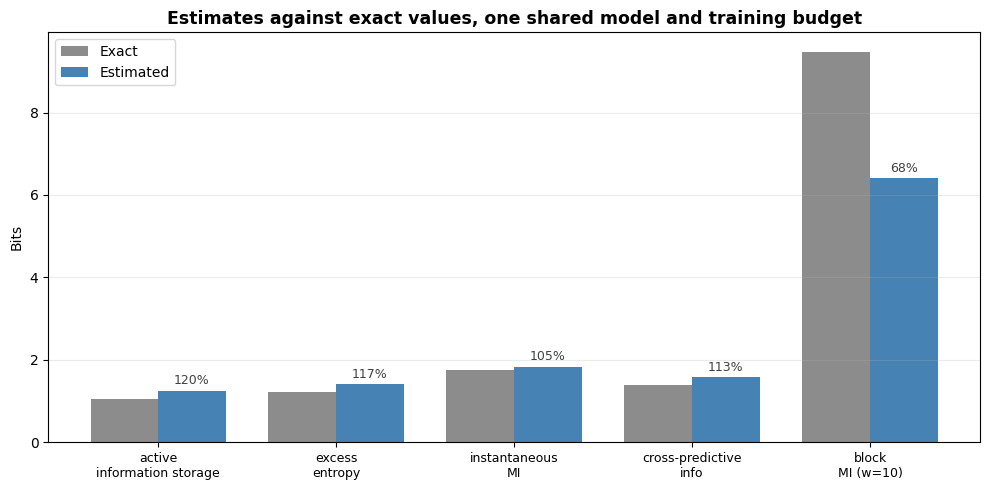

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(estimated)
idx = np.arange(len(names))
width = 0.38

ax.bar(idx - width/2, [truth[n] for n in names], width, label='Exact', color='0.55')
ax.bar(idx + width/2, [estimated[n] for n in names], width, label='Estimated',
       color='steelblue')

for i, n in enumerate(names):
    ratio = estimated[n] / truth[n]
    ax.text(i + width/2, estimated[n] + 0.15, f'{ratio:.0%}', ha='center',
            fontsize=9, color='0.25')

ax.set_xticks(idx)
ax.set_xticklabels([n.replace(' ', '\n', 1) for n in names], fontsize=9)
ax.set_ylabel('Bits')
ax.set_title('Estimates against exact values, one shared model and training budget',
             fontsize=12.5, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

Two different failure directions, and they have different causes.

**The intensive quantities come out slightly high.** Active information storage,
excess entropy, instantaneous MI and cross-predictive information all land above
their exact values, by roughly 10 to 20%. That is worth dwelling on, because
InfoNCE is a *lower* bound and a lower bound should not exceed the truth.

It is not a fluke. Measuring active information storage across eight independent
seeds gives a mean of 1.110 against an exact 1.050, a gap of 4.2 standard
errors, with 7 of 8 seeds above the truth. The bias is real.

The natural suspect is train/test leakage, since these arrays are cut at stride
1 and consecutive samples share all but one timepoint. That suspect is wrong,
and it is worth seeing how it was ruled out, because the reasoning is reusable.

First the geometry. At the default split the buffer between train and test
blocks is around 120 windows. Each window spans 8 timepoints, so train and test
windows share **zero** raw timepoints, and at `tau = 9.5` bins the residual
correlation across 120 bins is of order `1e-6`.

Then the direct test, which is stronger than the geometry. Subsampling every
8th window removes window overlap entirely, and if overlap were the cause the
bias should fall. It **rose**, from +5.9% to +13.5%, consistently across six
paired seeds. Removing the suspected cause made the effect larger, which
falsifies the hypothesis rather than merely failing to support it.

A third check: varying the correlation timescale over `tau` from 1.4 to 19.5
bins leaves the bias between 0.028 and 0.060 bits, flat within a factor of two,
while any cross-boundary correlation term would move by several orders of
magnitude across that range.

**The cause is in the table above, in the held-out column.** The held-out value
is below the reported one for every quantity, and for three of the five it is
also below the exact value, which is how a lower bound should behave.

A single run is noisy, so the population claim needs more than one. Across eight
independent seeds on active information storage, the held-out estimate averages
0.984 against an exact 1.050 and lands below the truth in 6 of 8 runs, while the
reported value averages 1.110 and lands above it in 7 of 8. Note that the run
in the table is one of the seeds where the held-out value came out high, which
is worth seeing: the guarantee is about the estimator's behaviour on average,
not a promise about any individual fit.

They differ because they are different quantities. The library selects the epoch
that maximises held-out test MI, then reports the **train-side** MI at that
epoch. So `mi_estimate` is an in-sample evaluation, and in-sample evaluation is
optimistic for the same reason it is optimistic anywhere in supervised learning:
the critic has seen those samples. `details['test_mi']` is the held-out number.

This explains the earlier observations too. The bias doubled when the effective
sample count fell eightfold, because a smaller training set is easier for a
fixed-capacity critic to fit. It stayed flat across the `tau` sweep, because
overfitting scales with the capacity-to-data ratio rather than with correlation
length.

**Which number should you report?** The train-side value is the library's
default because it is the less noisy of the two and, with the epoch chosen on
held-out data, it is not a naive best-case. But when you want a conservative
figure, or when you are close to a claim that depends on the exact magnitude,
`details['test_mi']` is the one that carries the lower-bound guarantee.
Tutorial 7 covers the bias-correction machinery that addresses this properly.

**The extensive quantity comes out badly low.** Block MI at `w = 10` reports
about two-thirds of its true value, and that is Tutorial 4's ceiling exactly:
the target is 9.5 bits against a batch-128 range of 7.

So the same estimator, the same data and the same training budget produce a mild
overestimate on the intensive quantities and a severe underestimate on the
extensive one. Neither is a bug. Both are properties you would want to know
about before reporting a number, and neither is visible without something to
compare against.

## 5. Key Takeaways

- **Active information storage is what a process spends; excess entropy is what
  it holds.** `AIS <= E_X` always, and they coincide when the future window is a
  single step. The gap between them is a real property of the process.

- **`k` is a model order.** Raise it until the answer stops moving. Different
  quantities converge at different `k`, so check each one rather than reusing a
  number.

- **Entropy rate is absent deliberately.** It is not a mutual information, so it
  is coordinate-dependent for continuous variables and outside what these
  estimators can report.

- **Check units before comparing.** Bits per bin, bits per window and plain bits
  are three different things, and only one of them survives a change of window
  size.

- **`mi_estimate` is an in-sample number.** It is the train-side MI at an epoch
  chosen on held-out data, so it runs optimistic, here by about 6% against a
  known truth. `details['test_mi']` is the held-out value and behaves as a
  proper lower bound. The gap between them widens as data shrinks.

- **Estimates err in both directions, for different reasons.** Intensive
  quantities came out high, from in-sample optimism. The extensive one came out
  a third low, from the ceiling. Direction of error is diagnostic.

- **On real data you cannot see any of this.** The oracle comparison exists so
  that you know what to expect when the comparison is unavailable.

## Common Mistakes

1. **Comparing block MI against a rate.** Different units. Dividing block MI by
   the window size still does not give the rate, because the block carries the
   subextensive part as well.

2. **Reusing one `k` across quantities.** Excess entropy needed more history
   than active information storage on the same process. Sweep each.

3. **Reading a rising `k`-curve as long-timescale structure.** It is also what
   growing input dimension does to the bias. You need bias correction to tell
   them apart.

4. **Dropping silent bins before building offsets.** The surviving indices are
   then no longer one bin apart, so every offset silently means something else.
   Keep them, and check `window_retention`.

5. **Trusting an estimate because it looks reasonable.** Every number in
   Section 4 looked reasonable. Four were high and one was a third too low.

## What's Next

**Tutorial 6** breaks the symmetry. Every quantity here is symmetric in its two
arguments or concerns one process alone, so none of them can say which process
drives which. Conditioning a process on its *own* past changes that, which gives
transfer entropy, instantaneous exchange and the directed information rate, tied
together by a conservation law that holds exactly.